[[1.89526244]
 [1.58883831]
 [1.52383445]
 [1.53548522]
 [1.79944889]]
[[8.47006009]
 [9.58907468]
 [9.54207542]
 [9.33473226]
 [8.84638245]]


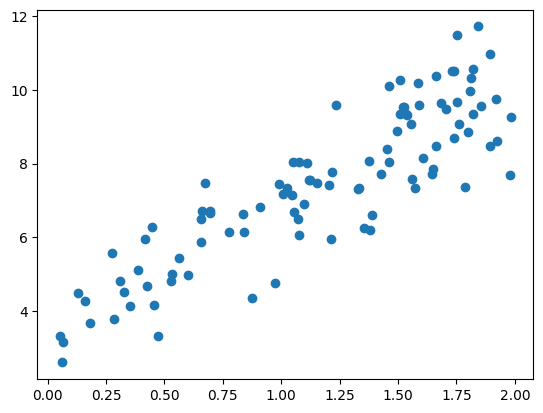

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = 2 * np.random.rand(100,1) # 100 rows × 1 column
print(X[:5])
Y =  4 + 3 * X + np.random.randn(100, 1) # Normal (Gaussian)
print(Y[:5])
plt.scatter(X,Y)
plt.show()

In [2]:
# let’s compute θˆ using the Normal Equation
X_b = np.c_[np.ones((100, 1)), X] # SHOUT BIAS
''' IMPORTANT '''
'''We will use the inv()
function from NumPy’s linear algebra module (np.linalg) to compute the
inverse of a matrix, and the dot() method for matrix multiplication:'''
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
'''y = 4 + 3x1 + Gaussian noise'''

'y = 4 + 3x1 + Gaussian noise'

In [3]:
theta_best

array([[3.51402098],
       [3.34029214]])

In [4]:
''' θ1 = 3.4 and θ2 = 0.75'''
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new] # add Bias
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.51402098],
       [10.19460527]])

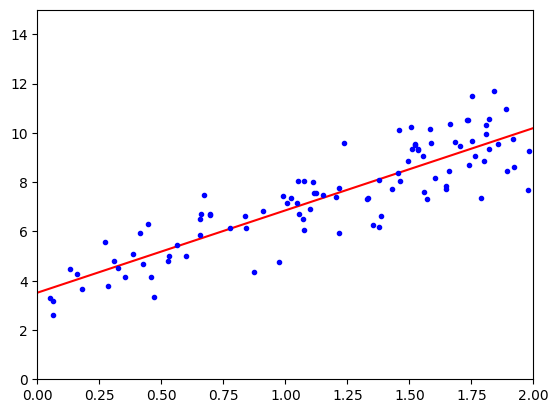

In [5]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, Y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [6]:
''' Moore-Penrose inverse '''
np.linalg.pinv(X_b).dot(Y)  # PROOF PENDING

array([[3.51402098],
       [3.34029214]])

In [7]:
''' Standardize features (mean 0, variance 1), or Normalize to a similar range '''

' Standardize features (mean 0, variance 1), or Normalize to a similar range '

## Gradient Descent

In [8]:
eta = 0.1
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1)
for iteration in range(n_iterations):
    grad = 2 / m * X_b.T.dot(X_b.dot(theta) - Y)
    theta = theta - eta * grad

theta    

array([[3.51402098],
       [3.34029214]])

## SGD

In [9]:
n_epochs = 50
t0, t1 = 5, 50   # Learning Schedule PARAMS
def learning(t):
    return t0 / (t + t1)
theta = np.random.randn(2,1)
for epoch in range(n_epochs):
    for i in range(m):
        index = np.random.randint(m)
        xi =  X_b[index:index+1]
        yi = Y[index:index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta)-yi)
        eta = learning(epoch * m + i)
        theta = theta - eta * gradients
''' While the Batch Gradient Descent code iterated 1,000 times through
the whole training set, this code goes through the training set only 50 times
and reaches a pretty good solution '''

' While the Batch Gradient Descent code iterated 1,000 times through\nthe whole training set, this code goes through the training set only 50 times\nand reaches a pretty good solution '

In [10]:
theta

array([[3.5175977 ],
       [3.33875773]])

## Polynomial Regression

[[-2.26631492]
 [ 1.73459548]
 [ 0.13479784]
 [-0.03210648]
 [ 1.01226248]]
[[1.60556402]
 [3.81175705]
 [2.39680449]
 [3.59574937]
 [3.51283701]]


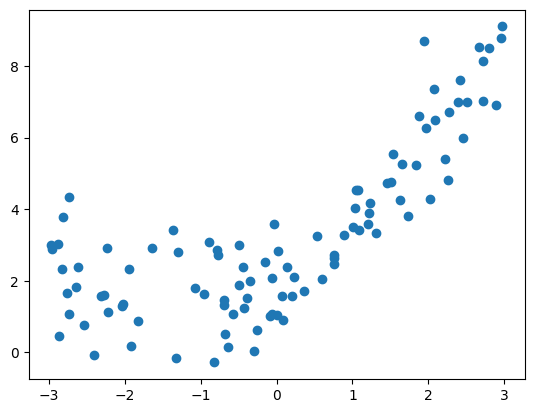

In [11]:
import numpy as np
import matplotlib.pyplot as plt
m = 100
X = 6 * np.random.rand(m,1) - 3
Y = 0.45 * X ** 2 + X + 2 + np.random.randn(m, 1) 
print(X[:5])
print(Y[:5])
plt.scatter(X, Y)
plt.show()


In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0]) # Extra coloumns for sq of each feature

[-2.26631492]
[-2.26631492  5.13618334]


In [13]:
from sklearn.linear_model import LinearRegression
a = LinearRegression()
a.fit(X_poly, Y)
a.intercept_, a.coef_

(array([2.01129649]), array([[1.04986419, 0.40820655]]))

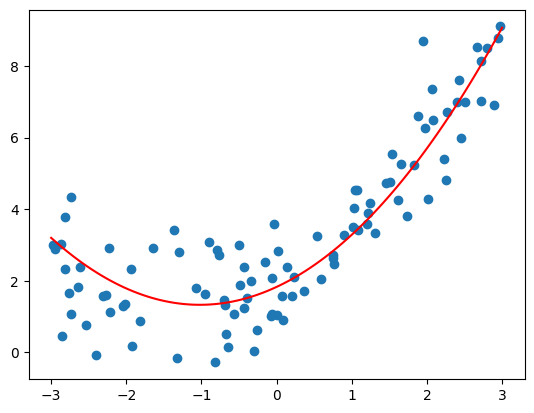

In [14]:
x = np.linspace(-3,3,100)
y = 0.4785362*x**2 + 0.97837064*x + 1.82805253
plt.plot(x, y, "r")
plt.scatter(X, Y)
plt.show()

## FUCCK AROUND AND FIND OUT

## Learning Curve

In [19]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_lc(model, X, Y):
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)
    t_e, v_e = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], Y_train[:m])
        Y_train_p = model.predict(X_train[:m])
        Y_val_p = model.predict(X_val) # SIZE REMIAIN FIXED AT EACH ITERATION
        t_e.append(mean_squared_error(Y_train[:m], Y_train_p))
        v_e.append(mean_squared_error(Y_val, Y_val_p))
    plt.plot(np.sqrt(t_e), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(v_e), "b--", linewidth=2, label="test")      
    

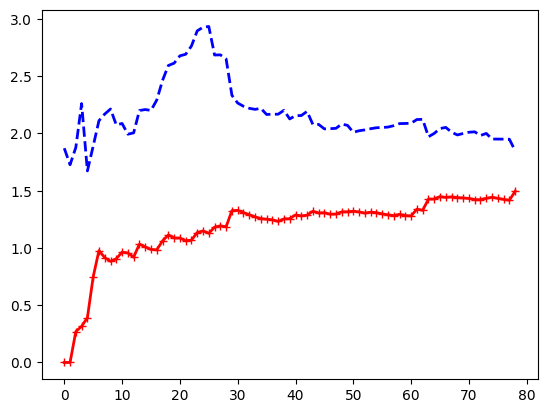

In [21]:
plot_lc(a, X, Y) # UNDERFIT

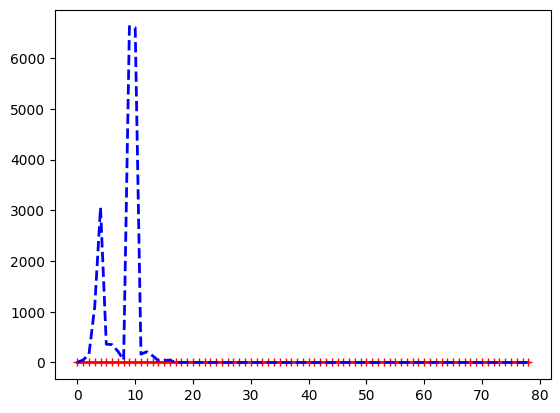

In [26]:
## LETS USE A CURVE OF deg = 10
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
("poly_features", PolynomialFeatures(degree=10,
include_bias=False)),
("a", LinearRegression()),
])
plot_lc(polynomial_regression, X, Y) # OVERFIT